In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import scipy.stats

select dataset to lookat 
  1) East_14 7th of Jan 2) East_16, 3)Draco_2 , 4)East_14 11th of Jan 4


Frequency    4.736553
Power        0.166581
Name: 0, dtype: float64


,Frequency,Power
0,4.736553,0.166581
95,72.754598,0.144706
1,5.452532,0.127617
94,72.038619,0.118840
96,73.470578,0.095111


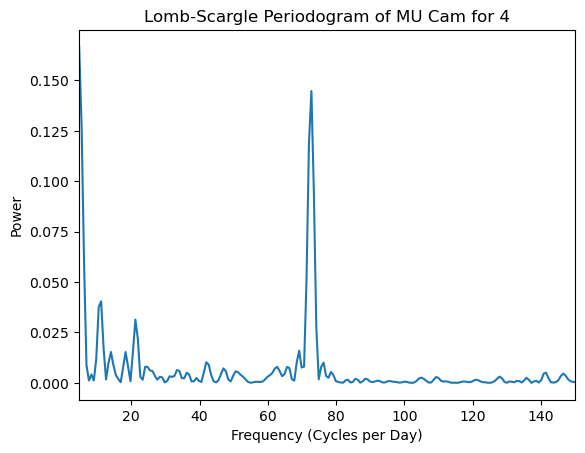

In [5]:
datasets=['East_14_Measurements_subset.dat','East_16_Measurements_subset.dat','Draco_2_Measurements_subset.dat','East_14_2022_01_11_Measurements_subset.dat']
chosen_set=int(input('select dataset to lookat \n  1) East_14 7th of Jan 2) East_16, 3)Draco_2 , 4)East_14 11th of Jan'))

if chosen_set==1:
    chosendataset=datasets[0]
    
    exposure_time=30

    
    fmax=(1/(2*exposure_time))*86400

    measurement_time=(113/730) #in days
    
    fmin=(2/measurement_time)
          
elif chosen_set==2:
    chosendataset=datasets[1]
    
    exposure_time=60
    
    fmax=(1/(2*exposure_time))*86400

    measurement_time=(19/240) #in days
    
    fmin=(2/measurement_time)
    
elif chosen_set==3:
    chosendataset=datasets[2]

    exposure_time=60

    fmax=(1/(2*exposure_time))*86400

    measurement_time=(167/480) #in days
    
    fmin=(2/measurement_time)

elif chosen_set==4:

    chosendataset=datasets[3]

    exposure_time=15

    measurement_time= 0.422248 #in days

    fmin=(2/measurement_time)


    
    
df = pd.read_csv(chosendataset, sep='\t')


time = df['JD_UTC'].values 
magnitude = df['Source_AMag_T1'].values

df['flux']=10**(-magnitude/2.5)
flux=df['flux']

# MU Cam orbital period (4.7 hr) = ~5 cycles/day

# MU Cam spin period (20 min) = ~72 cycles/day

frequency = np.linspace(fmin, fmax, 1000)


power = LombScargle(time, flux).power(frequency)



fig, ax = plt.subplots()
ax.plot(frequency, power)
plt.title(f'Lomb-Scargle Periodogram of MU Cam for {chosen_set}')
plt.xlabel('Frequency (Cycles per Day)')
plt.xlim(fmin,150)
plt.ylabel('Power')



ls_df = pd.DataFrame({
    'Frequency': frequency,
    'Power': power
})

peak_index = ls_df['Power'].idxmax()
absolute_peak = ls_df.loc[peak_index]
print(absolute_peak)


top_5_peaks = ls_df.sort_values(by='Power', ascending=False).head(5)
top_5_peaks

In [6]:
#combined lomb scargle
data=pd.read_csv('DATACOMBO.dat', sep='\t')
data

,#,Label,Source_AMag_T1,Source_AMag_Err_T1,JD_UTC
0,1,aligned_ad0045_out.fits,14.441387,0.113384,2.460731e+06
1,2,aligned_ad0046_out.fits,14.957626,0.176749,2.460731e+06
2,3,aligned_ad0047_out.fits,14.599827,0.023250,2.460731e+06
3,4,aligned_ad0048_out.fits,14.592830,0.029463,2.460731e+06
4,5,aligned_ad0049_out.fits,14.498407,0.056742,2.460731e+06
...,...,...,...,...,...
514,458,aligned_ad0703_out.fits,14.748320,0.121872,2.460733e+06
515,459,aligned_ad0704_out.fits,14.793148,0.141461,2.460733e+06
516,460,aligned_ad0705_out.fits,14.602719,0.127937,2.460733e+06
517,461,aligned_ad0706_out.fits,14.895775,0.162858,2.460733e+06


Frequency    73.691692
Power         0.141312
Name: 101, dtype: float64


,Frequency,Power
101,73.691692,0.141312
100,72.971972,0.136263
7,6.038038,0.113358
0,1.000000,0.107626
6,5.318318,0.085884


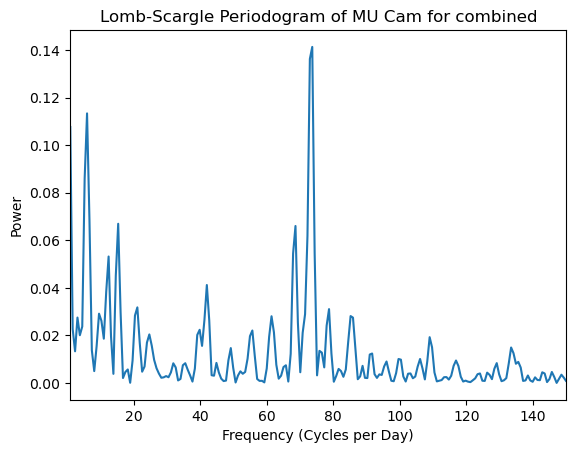

In [28]:
time = data['JD_UTC'].values 
magnitude = data['Source_AMag_T1'].values

data['flux']=10**(-magnitude/2.5)
flux=data['flux']

# MU Cam orbital period (4.7 hr) = ~5 cycles/day

# MU Cam spin period (20 min) = ~72 cycles/day

fmax=(1/(2*60))*86400
#fmin=(2/measurement_time)

frequency = np.linspace(1, fmax , 1000)


power = LombScargle(time, flux).power(frequency)



fig, ax = plt.subplots()
ax.plot(frequency, power)
plt.title(f'Lomb-Scargle Periodogram of MU Cam for combined')
plt.xlabel('Frequency (Cycles per Day)')
plt.xlim(1,150)
plt.ylabel('Power')




ls_df = pd.DataFrame({
    'Frequency': frequency,
    'Power': power
})

peak_index = ls_df['Power'].idxmax()
absolute_peak = ls_df.loc[peak_index]
print(absolute_peak)

top_5_peaks = ls_df.sort_values(by='Power', ascending=False).head(5)
top_5_peaks


,#,Label,Source_AMag_T1,Source_AMag_Err_T1,JD_UTC,flux
0,1,aligned_ad0045_out.fits,14.441387,0.113384,2.460731e+06,1.672805e-06
1,2,aligned_ad0046_out.fits,14.957626,0.176749,2.460731e+06,1.039799e-06
2,3,aligned_ad0047_out.fits,14.599827,0.023250,2.460731e+06,1.445670e-06
3,4,aligned_ad0048_out.fits,14.592830,0.029463,2.460731e+06,1.455017e-06
4,5,aligned_ad0049_out.fits,14.498407,0.056742,2.460731e+06,1.587220e-06
...,...,...,...,...,...,...
514,458,aligned_ad0703_out.fits,14.748320,0.121872,2.460733e+06,1.260875e-06
515,459,aligned_ad0704_out.fits,14.793148,0.141461,2.460733e+06,1.209876e-06
516,460,aligned_ad0705_out.fits,14.602719,0.127937,2.460733e+06,1.441824e-06
517,461,aligned_ad0706_out.fits,14.895775,0.162858,2.460733e+06,1.100753e-06


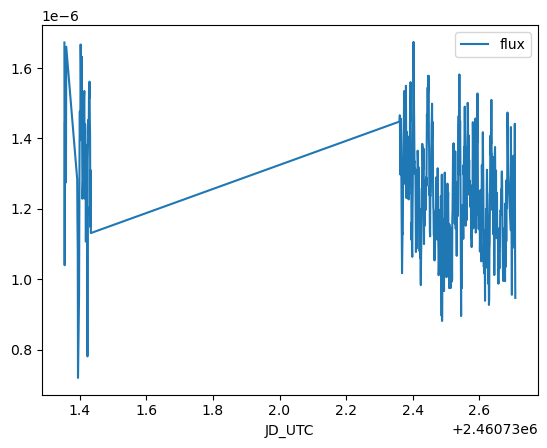

In [14]:
time = data['JD_UTC'].values 
magnitude = data['Source_AMag_T1'].values

data['flux']=10**(-magnitude/2.5)
flux=data['flux']

data.plot(x='JD_UTC', y='flux')

data

In [15]:

bootstrapped_data = data.sample(n=1000, replace=True)
bootstrapped_data=bootstrapped_data.sort_values(by='JD_UTC')

bootstrapped_data

,#,Label,Source_AMag_T1,Source_AMag_Err_T1,JD_UTC,flux
0,1,aligned_ad0045_out.fits,14.441387,0.113384,2.460731e+06,1.672805e-06
0,1,aligned_ad0045_out.fits,14.441387,0.113384,2.460731e+06,1.672805e-06
0,1,aligned_ad0045_out.fits,14.441387,0.113384,2.460731e+06,1.672805e-06
1,2,aligned_ad0046_out.fits,14.957626,0.176749,2.460731e+06,1.039799e-06
1,2,aligned_ad0046_out.fits,14.957626,0.176749,2.460731e+06,1.039799e-06
...,...,...,...,...,...,...
515,459,aligned_ad0704_out.fits,14.793148,0.141461,2.460733e+06,1.209876e-06
515,459,aligned_ad0704_out.fits,14.793148,0.141461,2.460733e+06,1.209876e-06
516,460,aligned_ad0705_out.fits,14.602719,0.127937,2.460733e+06,1.441824e-06
517,461,aligned_ad0706_out.fits,14.895775,0.162858,2.460733e+06,1.100753e-06


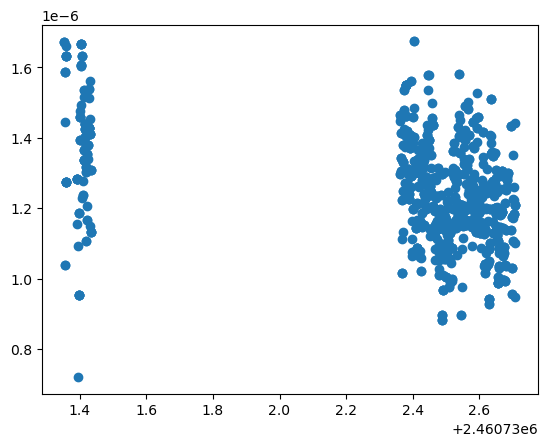

In [16]:
time_sampled = bootstrapped_data['JD_UTC'].values 
magnitude = bootstrapped_data['Source_AMag_T1'].values

bootstrapped_data['flux']=10**(-magnitude/2.5)
flux_sampled=bootstrapped_data['flux']

plt.scatter(time_sampled,flux_sampled)




1.0


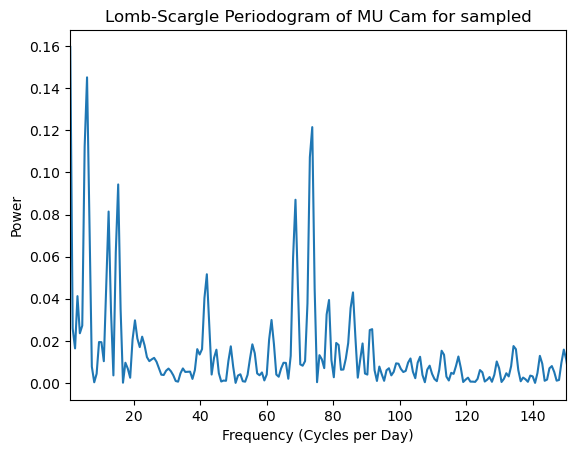

In [23]:
frequency = np.linspace(1, fmax, 1000)


power = LombScargle(time_sampled, flux_sampled).power(frequency)



fig, ax = plt.subplots()
ax.plot(frequency, power)
plt.title(f'Lomb-Scargle Periodogram of MU Cam for sampled')
plt.xlabel('Frequency (Cycles per Day)')
plt.xlim(1,150)
plt.ylabel('Power')



ls_df = pd.DataFrame({
    'Frequency': frequency,
    'Power': power
})

peak_index = ls_df['Power'].idxmax()
absolute_peak = ls_df.loc[peak_index]
print(absolute_peak['Frequency'])



In [24]:
data

,#,Label,Source_AMag_T1,Source_AMag_Err_T1,JD_UTC,flux
0,1,aligned_ad0045_out.fits,14.441387,0.113384,2.460731e+06,1.672805e-06
1,2,aligned_ad0046_out.fits,14.957626,0.176749,2.460731e+06,1.039799e-06
2,3,aligned_ad0047_out.fits,14.599827,0.023250,2.460731e+06,1.445670e-06
3,4,aligned_ad0048_out.fits,14.592830,0.029463,2.460731e+06,1.455017e-06
4,5,aligned_ad0049_out.fits,14.498407,0.056742,2.460731e+06,1.587220e-06
...,...,...,...,...,...,...
514,458,aligned_ad0703_out.fits,14.748320,0.121872,2.460733e+06,1.260875e-06
515,459,aligned_ad0704_out.fits,14.793148,0.141461,2.460733e+06,1.209876e-06
516,460,aligned_ad0705_out.fits,14.602719,0.127937,2.460733e+06,1.441824e-06
517,461,aligned_ad0706_out.fits,14.895775,0.162858,2.460733e+06,1.100753e-06


In [32]:
frequency_array=[]
frequency = np.linspace(72.6, 73, 1000)

for i in range (1,3000):

    #BOOTSRAPPING
    bootstrapped_data = data.sample(n=len(data), replace=True)
    
    bootstrapped_data=bootstrapped_data.sort_values(by='JD_UTC')


    time_sampled = bootstrapped_data['JD_UTC'].values 
    magnitude = bootstrapped_data['Source_AMag_T1'].values

    bootstrapped_data['flux']=10**(-magnitude/2.5)
    flux_sampled=bootstrapped_data['flux']
    


    #LOMB SCARGLE
    power = LombScargle(time_sampled, flux_sampled).power(frequency)
    
    ls_df = pd.DataFrame({
    'Frequency': frequency,
    'Power': power
    })
    
    peak_index = ls_df['Power'].idxmax()
    absolute_peak = ls_df.loc[peak_index]
    
    frequency_array.append(absolute_peak['Frequency'])

#frequency_array
freq_array_spin = frequency_array.copy()

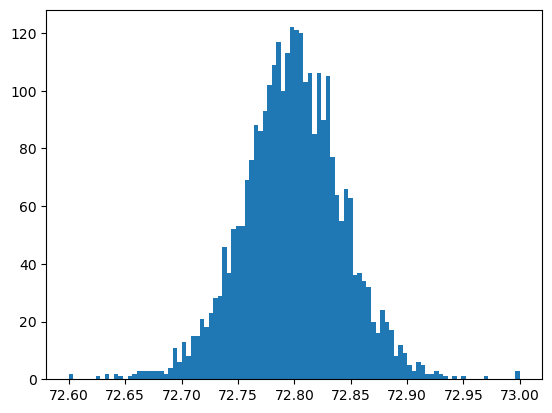

 the mean frequency is 72.79830180297003
the standard deviation is 0.04465876075902503


In [144]:
plt.hist(frequency_array,bins=100)
plt.show()
print(f' the mean frequency is {np.mean(frequency_array)}')
print(f'the standard deviation is {np.std(frequency_array)}')

In [33]:
frequency_array=[]
frequency = np.linspace(4.8, 5.3, 1000)

for i in range (1,3000):

    #BOOTSRAPPING
    bootstrapped_data = data.sample(n=len(data), replace=True)
    
    bootstrapped_data=bootstrapped_data.sort_values(by='JD_UTC')


    time_sampled = bootstrapped_data['JD_UTC'].values 
    magnitude = bootstrapped_data['Source_AMag_T1'].values

    bootstrapped_data['flux']=10**(-magnitude/2.5)
    flux_sampled=bootstrapped_data['flux']
    


    #LOMB SCARGLE
    power = LombScargle(time_sampled, flux_sampled).power(frequency)
    
    ls_df = pd.DataFrame({
    'Frequency': frequency,
    'Power': power
    })
    
    peak_index = ls_df['Power'].idxmax()
    absolute_peak = ls_df.loc[peak_index]
    
    frequency_array.append(absolute_peak['Frequency'])

#frequency_array
freq_array_orb = frequency_array.copy()

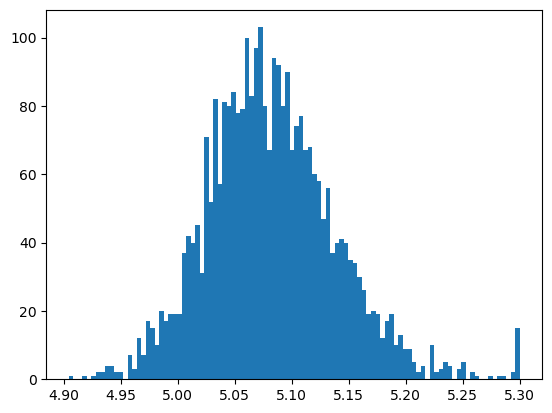

 the mean frequency is 5.082426307601366
the standard deviation is 0.05663168774070791


In [148]:
plt.hist(frequency_array,bins=100)
plt.show()
print(f' the mean frequency is {np.mean(frequency_array)}')
print(f'the standard deviation is {np.std(frequency_array)}')

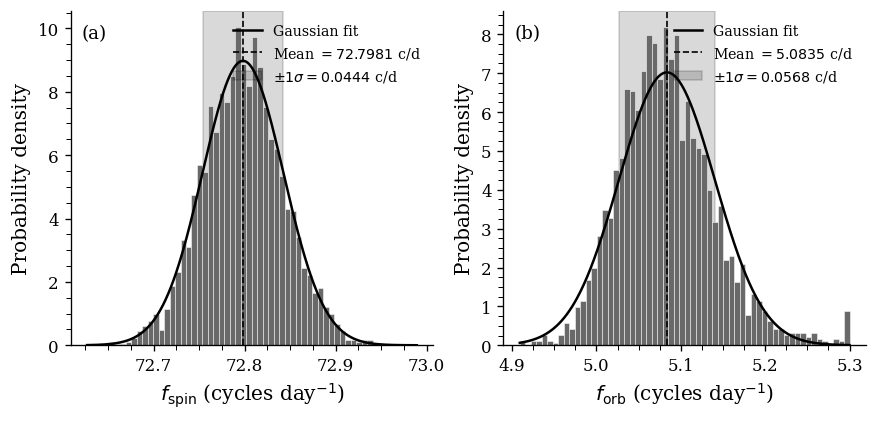

Fig 3 saved -> fig3_bootstrap_histograms.pdf / .png

Spin:    mu = 72.79813,  sigma = 0.04444  c/d
Orbital: mu = 5.08352,  sigma = 0.05684  c/d


In [34]:
# ============================================================
#  ERROR APPENDIX -- Bootstrap Histogram Figure
#
#  ADD THIS CODE to your notebook immediately after your two
#  bootstrap loops. Before running this cell, rename your
#  frequency_array outputs so both are available:
#
#    After the SPIN bootstrap loop, add:
#        freq_array_spin = frequency_array.copy()
#
#    After the ORBITAL bootstrap loop, add:
#        freq_array_orb = frequency_array.copy()
#
#  Then run this cell to produce fig3_bootstrap_histograms.pdf
# ============================================================

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy.stats as stats

matplotlib.rcParams.update({
    'font.family'       : 'serif',
    'font.size'         : 11,
    'axes.labelsize'    : 12,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : False,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
})

# ---- Your bootstrap results (paste in if running standalone) ----
# freq_array_spin and freq_array_orb must exist from bootstrap loops
# e.g. freq_array_spin = [72.73, 72.80, ...]  (3000 values)

# ---- Compute statistics ----
mu_spin  = np.mean(freq_array_spin)
sig_spin = np.std(freq_array_spin)

mu_orb   = np.mean(freq_array_orb)
sig_orb  = np.std(freq_array_orb)

# ---- Build figure: two panels side by side ----
fig3, (ax_s, ax_o) = plt.subplots(
    1, 2,
    figsize=(7.2, 3.4),
    constrained_layout=True
)

def plot_bootstrap_hist(ax, freq_array, mu, sig, xlabel, panel_label):
    """Plot histogram with overlaid Gaussian fit and ±1sigma markers."""

    # Histogram (density=True so the Gaussian overlay integrates to 1)
    n, bins, patches = ax.hist(
        freq_array,
        bins=60,
        density=True,
        color='dimgray',
        edgecolor='white',
        linewidth=0.3,
        zorder=2
    )

    # Gaussian fit overlay
    x_fit = np.linspace(min(freq_array), max(freq_array), 500)
    y_fit = stats.norm.pdf(x_fit, mu, sig)
    ax.plot(x_fit, y_fit,
            color='black', linewidth=1.5, linestyle='-',
            label='Gaussian fit', zorder=4)

    # Mean line
    ax.axvline(mu, color='black', linestyle='--',
               linewidth=1.0, zorder=3,
               label=rf'Mean $= {mu:.4f}$ c/d')

    # ±1 sigma shaded region
    ax.axvspan(mu - sig, mu + sig,
               alpha=0.15, color='black', zorder=1,
               label=rf'$\pm1\sigma = {sig:.4f}$ c/d')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Probability density')
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
    ax.tick_params(which='minor', length=3)
    ax.legend(frameon=False, fontsize=8.5, loc='upper right')
    ax.text(0.03, 0.96, panel_label,
            transform=ax.transAxes, fontsize=11, va='top')


plot_bootstrap_hist(
    ax_s, freq_array_spin, mu_spin, sig_spin,
    xlabel=r'$f_{\rm spin}$ (cycles day$^{-1}$)',
    panel_label='(a)'
)

plot_bootstrap_hist(
    ax_o, freq_array_orb, mu_orb, sig_orb,
    xlabel=r'$f_{\rm orb}$ (cycles day$^{-1}$)',
    panel_label='(b)'
)

plt.savefig('fig3_bootstrap_histograms.pdf')
plt.savefig('fig3_bootstrap_histograms.png')
plt.show()
print("Fig 3 saved -> fig3_bootstrap_histograms.pdf / .png")
print(f"\nSpin:    mu = {mu_spin:.5f},  sigma = {sig_spin:.5f}  c/d")
print(f"Orbital: mu = {mu_orb:.5f},  sigma = {sig_orb:.5f}  c/d")

RESULTS SUMMARY
Orbital:  f = 5.082 ± 0.057 c/d
          P = 4.722 ± 0.053 hr
          Literature f = 5.099 c/d  =>  0.29 sigma
Spin:     f = 72.798 ± 0.045 c/d
          P = 1186.8 ± 0.7 s  (19.781 ± 0.012 min)
          Literature f = 72.789 c/d  =>  0.22 sigma


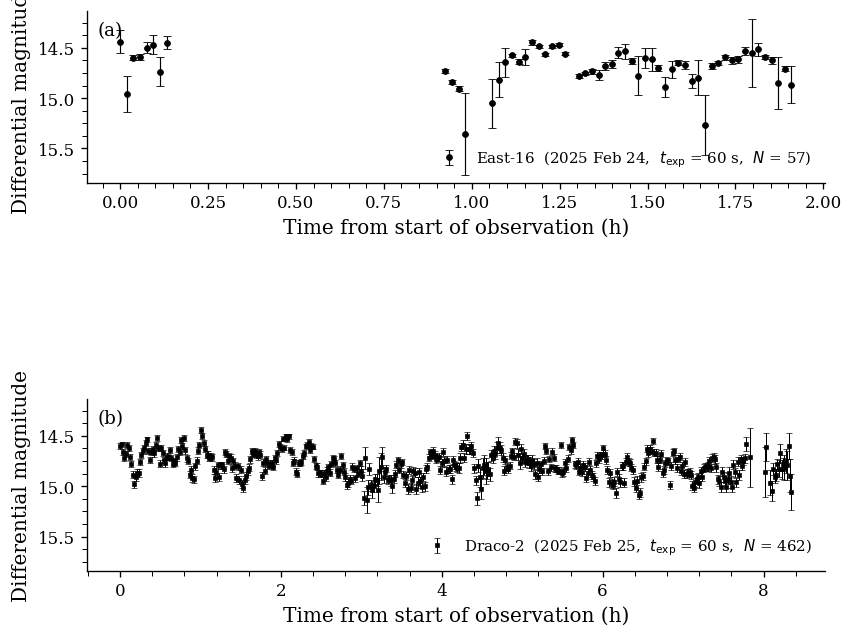

Fig 1 saved -> fig1_lightcurve.pdf / .png

1% FAP thresholds:  broad=0.0405  orbital=0.0306  spin=0.0398


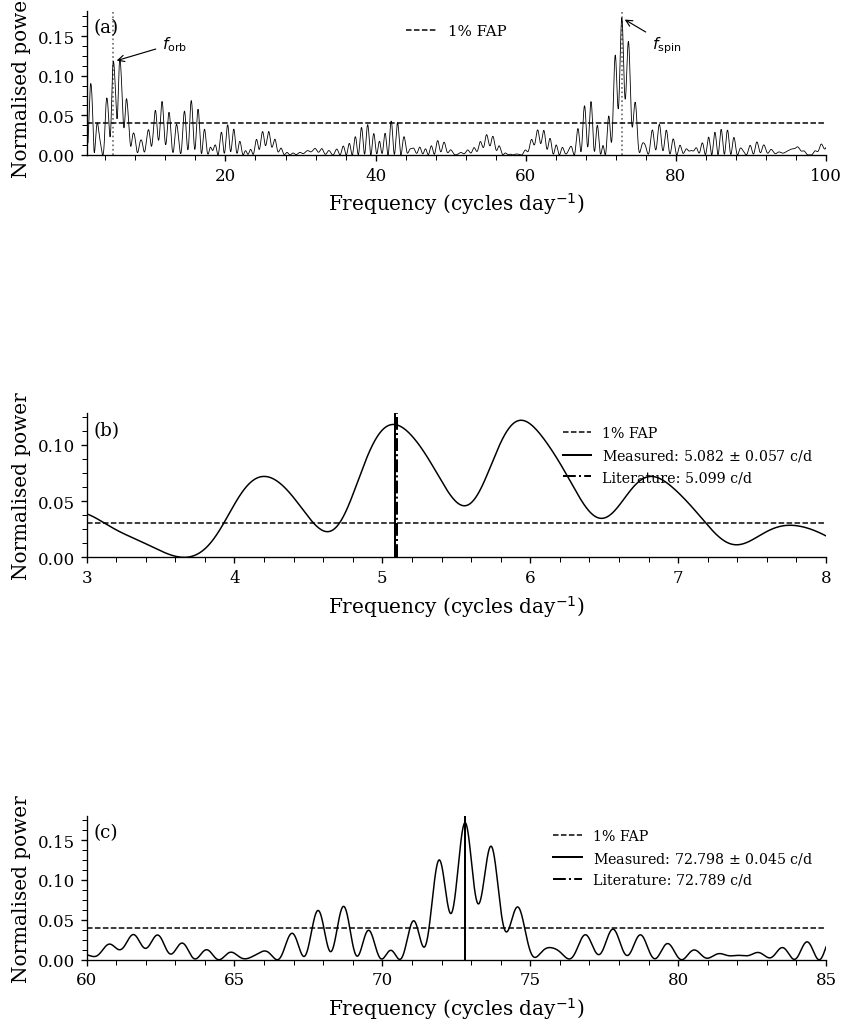

Fig 2 saved -> fig2_periodogram.pdf / .png

LATEX TABLE VALUES
f_orb  measured : 5.082 \pm 0.057  c/d
P_orb  measured : 4.722 \pm 0.053  hr
f_orb  lit      : 5.099  c/d
P_orb  lit      : 4.707  hr
z_orb           : 0.29 sigma

f_spin measured : 72.798 \pm 0.045  c/d
P_spin measured : 1186.8 \pm 0.7  s
                  19.781 \pm 0.012  min
f_spin lit      : 72.789  c/d
P_spin lit      : 1187 s  (19.78 min)
z_spin          : 0.22 sigma


In [31]:
# ============================================================
#  MU Camelopardalis -- Results Figures for Lab Report
#  Add these cells to the END of your existing notebook,
#  or run as a standalone script in the same folder as
#  DATACOMBO.dat
#
#  Produces:
#    fig1_lightcurve.pdf / .png  -- two-panel light curve
#    fig2_periodogram.pdf / .png -- three-panel LS periodogram
#  and prints the final results summary for the LaTeX table.
# ============================================================
 
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy.timeseries import LombScargle
 
# ============================================================
# 0.  GLOBAL MATPLOTLIB SETTINGS
#     Durham guidelines: no title, no gridlines, no border,
#     labelled axes with units, error bars, different line
#     styles (not just colour) for accessibility.
# ============================================================
matplotlib.rcParams.update({
    # Font
    'font.family'       : 'serif',
    'font.size'         : 11,
    'axes.labelsize'    : 12,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 9,
    # Spines / grid
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : False,
    # Output quality
    'figure.dpi'        : 120,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
})
 
# ============================================================
# 1.  LOAD DATA
# ============================================================
data = pd.read_csv('DATACOMBO.dat', sep='\t')
 
# Split by observing night
#   East-16  : JD 2460731.xxx  (57 frames,  2025-02-24)
#   Draco-2  : JD 2460732.xxx  (462 frames, 2025-02-25)
e16 = data[data['JD_UTC'] < 2460732].copy().reset_index(drop=True)
d2  = data[data['JD_UTC'] >= 2460732].copy().reset_index(drop=True)
 
# Time in hours from the start of each respective night
e16['t_hr'] = (e16['JD_UTC'] - e16['JD_UTC'].min()) * 24.0
d2['t_hr']  = (d2['JD_UTC']  - d2['JD_UTC'].min())  * 24.0
 
# Flux conversion for LS (same as existing notebook code)
data['flux']     = 10**(-data['Source_AMag_T1'] / 2.5)
data['flux_err'] = data['flux'] * (np.log(10) / 2.5) * data['Source_AMag_Err_T1']
 
time     = data['JD_UTC'].values
flux     = data['flux'].values
# flux_err is available but not used in LS (consistent with existing notebook)
 
# ============================================================
# 2.  BOOTSTRAP RESULTS
#     Copy the mean & std values from your bootstrap runs.
#     These are already printed at the bottom of your notebook:
#       Spin   : mean = 72.79830, std = 0.04466
#       Orbital: mean = 5.08243,  std = 0.05663
# ============================================================
f_orb_meas  = 5.08243      # cycles/day  (bootstrap mean)
f_orb_err   = 0.05663      # 1-sigma     (bootstrap std)
 
f_spin_meas = 72.79830     # cycles/day
f_spin_err  = 0.04466
 
# --- Derived periods ------------------------------------------
P_orb_days    = 1.0 / f_orb_meas
P_orb_hr      = P_orb_days * 24.0
# Error propagation: P = 1/f  =>  sigma_P = sigma_f / f^2
P_orb_err_hr  = (f_orb_err / f_orb_meas**2) * 24.0
 
P_spin_s      = (1.0 / f_spin_meas) * 86400.0
P_spin_min    = P_spin_s / 60.0
P_spin_err_s  = (f_spin_err / f_spin_meas**2) * 86400.0
P_spin_err_min = P_spin_err_s / 60.0
 
# --- Literature values ----------------------------------------
# Ramsay et al. 2008 (or Araujo-Betancor et al. 2003)
f_orb_lit   = 24.0 / 4.707       # P_orb_lit = 4.707 hr  =>  5.0989 c/d
f_spin_lit  = 86400.0 / 1187.0   # P_spin_lit = 1187 s   =>  72.788 c/d
 
# --- Sigma discrepancies --------------------------------------
z_orb  = abs(f_orb_meas  - f_orb_lit)  / f_orb_err
z_spin = abs(f_spin_meas - f_spin_lit) / f_spin_err
 
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Orbital:  f = {f_orb_meas:.3f} ± {f_orb_err:.3f} c/d")
print(f"          P = {P_orb_hr:.3f} ± {P_orb_err_hr:.3f} hr")
print(f"          Literature f = {f_orb_lit:.3f} c/d  =>  {z_orb:.2f} sigma")
print(f"Spin:     f = {f_spin_meas:.3f} ± {f_spin_err:.3f} c/d")
print(f"          P = {P_spin_s:.1f} ± {P_spin_err_s:.1f} s  "
      f"({P_spin_min:.3f} ± {P_spin_err_min:.3f} min)")
print(f"          Literature f = {f_spin_lit:.3f} c/d  =>  {z_spin:.2f} sigma")
print("=" * 60)
 
# ============================================================
# 3.  FIGURE 1 -- LIGHT CURVE
#     Two panels (one per night), shared y-axis inverted
#     (brighter upward = standard astronomical convention).
#     Circles for East-16, squares for Draco-2.
#     Durham: error bars, different marker styles, no title,
#             no gridlines, axis labels with units.
# ============================================================
fig1, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(7.0, 5.2),
    sharey=True,
    gridspec_kw={'hspace': 0.52},
    constrained_layout=True
)
 
# --- Panel (a): East-16 ---
ax1.errorbar(
    e16['t_hr'], e16['Source_AMag_T1'],
    yerr=e16['Source_AMag_Err_T1'],
    fmt='o',
    color='black',
    markersize=3.5,
    markeredgewidth=0.5,
    capsize=2.5,
    linewidth=0,          # no connecting line between points
    elinewidth=0.7,
    ecolor='black',
    label='East-16  (2025 Feb 24,  $t_{\\rm exp}$ = 60 s,  $N$ = 57)'
)
ax1.invert_yaxis()        # astronomical convention; shared y inverts both panels
ax1.set_xlabel('Time from start of observation (h)')
ax1.set_ylabel('Differential magnitude')
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
ax1.tick_params(which='minor', length=3)
ax1.legend(loc='lower right', frameon=False)
# Panel label (inside, top-left corner)
ax1.text(0.015, 0.94, '(a)', transform=ax1.transAxes,
         fontsize=11, va='top')
 
# --- Panel (b): Draco-2 ---
ax2.errorbar(
    d2['t_hr'], d2['Source_AMag_T1'],
    yerr=d2['Source_AMag_Err_T1'],
    fmt='s',              # squares -- different shape, not just colour
    color='black',
    markersize=2.8,
    markeredgewidth=0.4,
    capsize=2.0,
    linewidth=0,
    elinewidth=0.6,
    ecolor='black',
    label='Draco-2  (2025 Feb 25,  $t_{\\rm exp}$ = 60 s,  $N$ = 462)'
)
ax2.set_xlabel('Time from start of observation (h)')
ax2.set_ylabel('Differential magnitude')
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
ax2.tick_params(which='minor', length=3)
ax2.legend(loc='lower right', frameon=False)
ax2.text(0.015, 0.94, '(b)', transform=ax2.transAxes,
         fontsize=11, va='top')
 
plt.savefig('fig1_lightcurve.pdf')
plt.savefig('fig1_lightcurve.png')
plt.show()
print("Fig 1 saved -> fig1_lightcurve.pdf / .png")
 
# ============================================================
# 4.  FIGURE 2 -- LOMB-SCARGLE PERIODOGRAM (three panels)
#
#  (a) Broad view  1.5 -- 100 c/d  showing both peaks
#  (b) Orbital zoom  3 -- 8 c/d   with FAP, measured, lit
#  (c) Spin zoom    60 -- 85 c/d   with FAP, measured, lit
#
#  WHY this range for (a)?
#    Using 1.5--100 c/d on a LINEAR axis captures BOTH the
#    orbital peak (~5 c/d) and the spin peak (~73 c/d) in one
#    panel, giving the reader the full picture of the power
#    spectrum before the zoomed panels show the details.
#    Going to 720 c/d would compress the region of interest.
#
#  Durham: different line styles (solid/dashed/dash-dot) so
#          the plot is meaningful in greyscale/print.
# ============================================================
 
N_FREQ = 10000   # way higher than N_data=519; standard oversampling
 
ls = LombScargle(time, flux)   # floating-mean LS (Zechmeister & Kürster 2009)
 
# --- (a) Broad -----------------------------------------------
f_broad   = np.linspace(1.5, 100.0, N_FREQ)
pwr_broad = ls.power(f_broad)
 
# FAP: Baluev (2008) analytical approximation, for the
#       specific frequency window [1.5, 100] c/d
try:
    fap_broad = ls.false_alarm_level(
        0.01, method='baluev',
        minimum_frequency=1.5, maximum_frequency=100.0
    )
except TypeError:                        # older astropy fallback
    fap_broad = ls.false_alarm_level(0.01, method='baluev')
 
# --- (b) Orbital zoom ----------------------------------------
f_orb_grid   = np.linspace(3.0, 8.0, N_FREQ)
pwr_orb_grid = ls.power(f_orb_grid)
 
try:
    fap_orb = ls.false_alarm_level(
        0.01, method='baluev',
        minimum_frequency=3.0, maximum_frequency=8.0
    )
except TypeError:
    fap_orb = ls.false_alarm_level(0.01, method='baluev')
 
# --- (c) Spin zoom -------------------------------------------
f_spin_grid   = np.linspace(60.0, 85.0, N_FREQ)
pwr_spin_grid = ls.power(f_spin_grid)
 
try:
    fap_spin = ls.false_alarm_level(
        0.01, method='baluev',
        minimum_frequency=60.0, maximum_frequency=85.0
    )
except TypeError:
    fap_spin = ls.false_alarm_level(0.01, method='baluev')
 
print(f"\n1% FAP thresholds:  broad={fap_broad:.4f}  "
      f"orbital={fap_orb:.4f}  spin={fap_spin:.4f}")
 
# --- Build figure --------------------------------------------
fig2, (ax_a, ax_b, ax_c) = plt.subplots(
    3, 1,
    figsize=(7.0, 8.5),
    gridspec_kw={'hspace': 0.58},
    constrained_layout=True
)
 
# ---- Panel (a): broad periodogram ----
ax_a.plot(f_broad, pwr_broad, color='black', linewidth=0.5, zorder=2)
ax_a.axhline(fap_broad, color='black', linestyle='--',
              linewidth=0.9, label='1% FAP', zorder=3)
 
# Mark peaks with dotted vertical lines + annotation arrows
pwr_at_orb  = pwr_broad[np.argmin(np.abs(f_broad - f_orb_meas))]
pwr_at_spin = pwr_broad[np.argmin(np.abs(f_broad - f_spin_meas))]
ax_a.axvline(f_orb_meas,  color='dimgray', linestyle=':', linewidth=1.0, zorder=1)
ax_a.axvline(f_spin_meas, color='dimgray', linestyle=':', linewidth=1.0, zorder=1)
 
ax_a.annotate(
    r'$f_{\rm orb}$',
    xy=(f_orb_meas, pwr_at_orb),
    xytext=(f_orb_meas + 6.5, pwr_broad.max() * 0.78),
    fontsize=9.5, ha='left',
    arrowprops=dict(arrowstyle='->', lw=0.7, color='black')
)
ax_a.annotate(
    r'$f_{\rm spin}$',
    xy=(f_spin_meas, pwr_at_spin),
    xytext=(f_spin_meas + 4.0, pwr_broad.max() * 0.78),
    fontsize=9.5, ha='left',
    arrowprops=dict(arrowstyle='->', lw=0.7, color='black')
)
 
ax_a.set_xlabel(r'Frequency (cycles day$^{-1}$)')
ax_a.set_ylabel('Normalised power')
ax_a.set_xlim(1.5, 100.0)
ax_a.set_ylim(bottom=0)
ax_a.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax_a.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
ax_a.tick_params(which='minor', length=3)
ax_a.legend(loc='upper center', frameon=False)
ax_a.text(0.01, 0.95, '(a)', transform=ax_a.transAxes, fontsize=11, va='top')
 
# ---- Panel (b): orbital peak zoom ----
ax_b.plot(f_orb_grid, pwr_orb_grid, color='black', linewidth=0.9, zorder=3)
 
ax_b.axhline(fap_orb, color='black', linestyle='--',
              linewidth=0.9, zorder=4,
              label='1% FAP')
ax_b.axvline(f_orb_meas, color='black', linestyle='-',
              linewidth=1.2, zorder=5,
              label=rf'Measured: {f_orb_meas:.3f} $\pm$ {f_orb_err:.3f} c/d')
ax_b.axvline(f_orb_lit, color='black', linestyle='-.',
              linewidth=1.2, zorder=5,
              label=rf'Literature: {f_orb_lit:.3f} c/d')
 
ax_b.set_xlabel(r'Frequency (cycles day$^{-1}$)')
ax_b.set_ylabel('Normalised power')
ax_b.set_xlim(3.0, 8.0)
ax_b.set_ylim(bottom=0)
ax_b.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax_b.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
ax_b.tick_params(which='minor', length=3)
ax_b.legend(loc='upper right', frameon=False, fontsize=8.5)
ax_b.text(0.01, 0.95, '(b)', transform=ax_b.transAxes, fontsize=11, va='top')
 
# ---- Panel (c): spin peak zoom ----
ax_c.plot(f_spin_grid, pwr_spin_grid, color='black', linewidth=0.9, zorder=3)
 
ax_c.axhline(fap_spin, color='black', linestyle='--',
              linewidth=0.9, zorder=4,
              label='1% FAP')
ax_c.axvline(f_spin_meas, color='black', linestyle='-',
              linewidth=1.2, zorder=5,
              label=rf'Measured: {f_spin_meas:.3f} $\pm$ {f_spin_err:.3f} c/d')
ax_c.axvline(f_spin_lit, color='black', linestyle='-.',
              linewidth=1.2, zorder=5,
              label=rf'Literature: {f_spin_lit:.3f} c/d')
 
ax_c.set_xlabel(r'Frequency (cycles day$^{-1}$)')
ax_c.set_ylabel('Normalised power')
ax_c.set_xlim(60.0, 85.0)
ax_c.set_ylim(bottom=0)
ax_c.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax_c.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
ax_c.tick_params(which='minor', length=3)
ax_c.legend(loc='upper right', frameon=False, fontsize=8.5)
ax_c.text(0.01, 0.95, '(c)', transform=ax_c.transAxes, fontsize=11, va='top')
 
plt.savefig('fig2_periodogram.pdf')
plt.savefig('fig2_periodogram.png')
plt.show()
print("Fig 2 saved -> fig2_periodogram.pdf / .png")
 
# ============================================================
# 5.  PRINT ALL VALUES NEEDED FOR THE LATEX TABLE
# ============================================================
print("\n" + "=" * 60)
print("LATEX TABLE VALUES")
print("=" * 60)
print(f"f_orb  measured : {f_orb_meas:.3f} \\pm {f_orb_err:.3f}  c/d")
print(f"P_orb  measured : {P_orb_hr:.3f} \\pm {P_orb_err_hr:.3f}  hr")
print(f"f_orb  lit      : {f_orb_lit:.3f}  c/d")
print(f"P_orb  lit      : 4.707  hr")
print(f"z_orb           : {z_orb:.2f} sigma")
print()
print(f"f_spin measured : {f_spin_meas:.3f} \\pm {f_spin_err:.3f}  c/d")
print(f"P_spin measured : {P_spin_s:.1f} \\pm {P_spin_err_s:.1f}  s")
print(f"                  {P_spin_min:.3f} \\pm {P_spin_err_min:.3f}  min")
print(f"f_spin lit      : {f_spin_lit:.3f}  c/d")
print(f"P_spin lit      : 1187 s  (19.78 min)")
print(f"z_spin          : {z_spin:.2f} sigma")
print("=" * 60)